# AI Study Assistant

**Author:** Tala Al-Hadawi  
**Training Programme:** SDAIA Academy – Building AI Agent Systems  
**Cohort Dates:** 26–30 July 2026   
**Workflow Pattern:** Orchestrator–Worker  


## Project Overview

The AI Study Assistant helps students study uploaded PDF materials. It can:

- Answer questions using the uploaded documents
- Generate concise summaries
- Create multiple-choice quizzes
- Combine several workers for requests such as a complete study pack
- Retrieve relevant evidence through RAG
- Remember conversation context and user preferences
- Pause for user approval before quiz generation
- Trace the complete workflow in LangSmith

## How to Run

1. Add `GROQ_API_KEY` and, optionally, `LANGSMITH_API_KEY` to Google Colab Secrets.
2. Select **Runtime → Restart session and run all**.
3. Upload at least one text-based study PDF when the upload cell appears.
4. Run the included QA, multi-worker, memory, and Human-in-the-Loop demonstrations.
5. During the Human-in-the-Loop demo, type `yes` or `no`. The workflow resumes the same checkpointed thread using `Command(resume=...)`.
6. After the latest run, capture new LangSmith screenshots from the `ai-study-assistant` project and add the measured finding in Phase 7.

All definitions are ordered before use. The Human-in-the-Loop step pauses before an approved, cost-incurring quiz-generation action.

## System Architecture

```text
                                User Request
                                     |
                                     v
                              Orchestrator
                       (structured multi-task plan)
                                     |
                 +-------------------+-------------------+
                 |                   |                   |
                 v                   v                   v
             QA Worker         Summary Worker       Quiz Worker
                 |                   |                   |
                 +-------------------+-------------------+
                                     |
                      Model-selected Retrieval Tool
                                     |
                                     v
                    FAISS Vector Store + Embeddings
                                     |
                                     v
                           Uploaded PDF Documents

Short-Term Memory: Checkpointer + thread_id
Long-Term Memory: Store + user_id
Human-in-the-Loop: interrupt() before Quiz Worker
Observability: LangSmith traces the complete workflow
```

## Workflow Design

The system follows a true **Orchestrator–Worker** pattern:

1. The **Orchestrator** analyses the request and creates a Pydantic-validated plan.
2. It may assign one task or several independent tasks to the QA, Summary, and Quiz workers.
3. Each study worker uses a tool-enabled LLM to select and call `search_study_material` with a focused query.
4. The workers generate structured, document-grounded outputs.
5. Quiz generation pauses for Human-in-the-Loop approval.
6. The **Synthesiser** combines all completed worker outputs into one final response.
7. Checkpointing, long-term storage, retries, fallbacks, and LangSmith tracing support the workflow.

# Phase 1 – Environment Setup

This phase installs the required libraries, loads API keys from Colab Secrets, enables LangSmith tracing, and initialises the language model.

Required Colab Secrets:

- `GROQ_API_KEY`
- `LANGSMITH_API_KEY` (optional, but required for tracing evidence)

In [1]:
%pip install -q langgraph langchain langchain-core langchain-community langchain-groq langchain-huggingface langsmith faiss-cpu sentence-transformers pymupdf pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import json
import os
import uuid
from collections import Counter
from pathlib import Path
from threading import Lock
from typing import Any, Literal

from google.colab import files, userdata
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyMuPDFLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.func import entrypoint, task
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, RetryPolicy, interrupt

/tmp/ipykernel_2249/91211725.py:14: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader, PyPDFLoader


In [3]:
# Load secrets without exposing them in the notebook.
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

try:
    LANGSMITH_API_KEY = userdata.get("LANGSMITH_API_KEY")
except Exception:
    LANGSMITH_API_KEY = None

if not GROQ_API_KEY:
    raise ValueError("Add GROQ_API_KEY to Colab Secrets before running the notebook.")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

if LANGSMITH_API_KEY:
    os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = "ai-study-assistant"

    # The rubric explicitly names the legacy LangChain variables, so both
    # naming conventions are set to the same project.
    os.environ["LANGCHAIN_API_KEY"] = LANGSMITH_API_KEY
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_PROJECT"] = "ai-study-assistant"

    print("LangSmith tracing enabled for project: ai-study-assistant")
else:
    os.environ["LANGSMITH_TRACING"] = "false"
    os.environ["LANGCHAIN_TRACING_V2"] = "false"
    print("LANGSMITH_API_KEY was not found. The workflow will run without tracing.")

LangSmith tracing enabled for project: ai-study-assistant


In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2,
)

connection_test = llm.invoke("Reply with exactly: LLM connection successful")
print(connection_test.content)


LLM connection successful


## Phase 1 Rubric Coverage

- Secure API-key handling through Colab Secrets
- Language-model initialisation
- LangSmith tracing configuration
- Reproducible dependency setup

# Phase 2 – Document Ingestion and RAG

The RAG pipeline performs the following steps:

1. Upload one or more PDF files.
2. Extract text with `PyMuPDFLoader`, with `PyPDFLoader` as a fallback.
3. Split the pages into overlapping chunks.
4. Generate Hugging Face embeddings.
5. Store the chunks in FAISS.
6. Retrieve semantically relevant evidence for each worker.

### RAG Strategy: 2-Step RAG

This project uses **2-Step RAG** because every study response must be grounded in the uploaded documents. A tool-enabled LLM selects the retrieval tool and writes a focused search query, but retrieval remains a mandatory single step that completes before structured answer generation.

This provides predictable evidence, preserves source metadata, and reduces unsupported responses. The design is not Agentic RAG because it does not use an iterative retrieve–reason–retrieve loop or allow workers to bypass grounding. Hybrid RAG would add unnecessary complexity for this focused PDF study-assistant use case.

In [5]:
# Upload one or more study PDFs.
uploaded_files = files.upload()
pdf_paths = [name for name in uploaded_files if name.lower().endswith(".pdf")]

if not pdf_paths:
    raise ValueError("Please upload at least one PDF file.")

print("Uploaded PDFs:", pdf_paths)

Saving 6. Constraint Satisfaction Problems.pdf to 6. Constraint Satisfaction Problems.pdf
Uploaded PDFs: ['6. Constraint Satisfaction Problems.pdf']


In [6]:
documents = []

for pdf_path in pdf_paths:
    try:
        loaded_pages = PyMuPDFLoader(pdf_path).load()
    except Exception as pymupdf_error:
        print(f"PyMuPDFLoader failed for {pdf_path}: {pymupdf_error}")
        print("Trying PyPDFLoader instead...")
        loaded_pages = PyPDFLoader(pdf_path).load()

    for page in loaded_pages:
        page.metadata["source"] = Path(pdf_path).name

    documents.extend(loaded_pages)

if not documents:
    raise ValueError("No pages could be extracted from the uploaded PDFs.")

print(f"Loaded {len(documents)} pages from {len(pdf_paths)} PDF file(s).")

Loaded 58 pages from 1 PDF file(s).


In [7]:
# Inspect a small sample before indexing.
for index, document in enumerate(documents[:5], start=1):
    preview = document.page_content.strip().replace("\n", " ")[:160]
    print(f"Page sample {index}: {len(document.page_content)} characters | {preview!r}")

Page sample 1: 46 characters | 'Chapter 6 Constraint Satisfaction Problems i s'
Page sample 2: 573 characters | 'Constraint Satisfaction Problems • Standard search problem: • A state is a “black box” – any data structure that supports successor function,  heuristic functio'
Page sample 3: 23 characters | 'Example: map-coloring 3'
Page sample 4: 233 characters | 'Example: map-coloring 1. Variables: {WA, NT, Q, NSW, V, SA, T} 2. Domains: Di = {red, green, blue} 3. Constraints: adjacent regions must have different colors: '
Page sample 5: 265 characters | 'Example: map-coloring Solutions are complete and consistent assignments. • Complete assignment: all variables are assigned. • Consistent assignment: no constrai'


In [8]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

all_chunks = text_splitter.split_documents(documents)
valid_chunks = [
    chunk for chunk in all_chunks
    if len(chunk.page_content.strip()) >= 80
]

# Keep non-empty chunks if the PDF consists mainly of short presentation slides.
if not valid_chunks:
    valid_chunks = [
        chunk for chunk in all_chunks
        if chunk.page_content.strip()
    ]

if not valid_chunks:
    raise ValueError("The uploaded PDF does not contain extractable text. A scanned PDF may require OCR.")

print(f"All chunks: {len(all_chunks)}")
print(f"Indexed chunks: {len(valid_chunks)}")

All chunks: 58
Indexed chunks: 45


In [9]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

vector_store = FAISS.from_documents(valid_chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

print("FAISS vector store and retriever created successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS vector store and retriever created successfully.


In [10]:
# Edit this value when demonstrating the notebook with a different course document.
DEMO_TOPIC = "constraint satisfaction problems"

retrieval_test = retriever.invoke(DEMO_TOPIC)
for index, document in enumerate(retrieval_test, start=1):
    source = Path(document.metadata.get("source", "uploaded PDF")).name
    page = document.metadata.get("page")
    page_label = f"page {page + 1}" if isinstance(page, int) else "page unknown"
    print(f"\nResult {index} — {source}, {page_label}")
    print(document.page_content[:350])


Result 1 — 6. Constraint Satisfaction Problems.pdf, page 2
Constraint Satisfaction Problems
• Standard search problem:
• A state is a “black box” – any data structure that supports successor function, 
heuristic function and goal test.
• CSP:
• A state is defined by variables !! with values from domains "! (factored 
representation)
• Goal test is a set of constraints specifying allowable combinations of v

Result 2 — 6. Constraint Satisfaction Problems.pdf, page 8
Constraint graph
8
• A binary CSP can be represented by a constraint graph: nodes are 
variables, arcs are constraints
WA
NT
SA
Q
NSW
V
T

Result 3 — 6. Constraint Satisfaction Problems.pdf, page 7
Varieties of CSP
• Constraints can be:
• Unary: apply to one variable. Example: SA ≠ green.
• Binary: relate two variables. Example: SA ≠ WA.
• N-ary (or higher-order) constraints: involve 3 or more variables. Example: 
Sudoku.
• A CSP with n-ary constraints can always be transformed to a CSP with 
binary constraints
• We focus o

## Phase 2 Rubric Coverage

- Real uploaded documents
- Text loading and overlapping chunking
- Hugging Face embedding generation
- FAISS vector database
- Semantic retrieval
- Source and page metadata retained
- Written justification for the selected **2-Step RAG** strategy

# Phase 3 – Agent Fundamentals

This phase defines:

- A real retrieval tool
- Pydantic structured-output schemas
- Specialised QA, Summary, and Quiz agents
- A structured orchestration plan
- A final synthesis schema

In [11]:
class SummaryOutput(BaseModel):
    summary: str = Field(description="A concise summary grounded in the retrieved material.")
    key_points: list[str] = Field(description="The most important facts from the material.")


class QAOutput(BaseModel):
    answer: str = Field(description="A direct answer grounded in the retrieved material.")


class QuizQuestion(BaseModel):
    question: str
    options: list[str] = Field(description="Exactly four answer options.", min_length=4, max_length=4)
    correct_answer: str
    explanation: str


class QuizOutput(BaseModel):
    questions: list[QuizQuestion]


class WorkerTask(BaseModel):
    worker: Literal["qa", "summary", "quiz"]
    instruction: str = Field(description="A specific instruction for the selected worker.")


class OrchestrationPlan(BaseModel):
    tasks: list[WorkerTask] = Field(
        description="One or more worker tasks required to complete the request.",
        min_length=1,
    )
    reason: str = Field(description="Why these workers were selected.")


class SynthesisOutput(BaseModel):
    final_answer: str = Field(description="A complete response combining all worker outputs.")

In [12]:
def _format_retrieved_documents(query: str) -> dict[str, Any]:
    docs = retriever.invoke(query)
    sources = []
    sections = []

    for document in docs:
        source_name = Path(document.metadata.get("source", "uploaded PDF")).name
        page = document.metadata.get("page")
        source_label = (
            f"{source_name}, page {page + 1}"
            if isinstance(page, int)
            else source_name
        )

        if source_label not in sources:
            sources.append(source_label)

        sections.append(
            f"[Source: {source_label}]\n{document.page_content.strip()}"
        )

    return {
        "query": query,
        "context": "\n\n".join(sections),
        "sources": sources,
    }


@tool
def search_study_material(query: str) -> str:
    """Retrieve relevant evidence from the uploaded study PDFs."""
    payload = _format_retrieved_documents(query)
    return json.dumps(payload, ensure_ascii=False)

In [13]:
tool_test = json.loads(
    search_study_material.invoke({"query": DEMO_TOPIC})
)

print("Retrieved sources:")
for source in tool_test["sources"]:
    print("-", source)

print("\nContext preview:")
print(tool_test["context"][:700])

Retrieved sources:
- 6. Constraint Satisfaction Problems.pdf, page 2
- 6. Constraint Satisfaction Problems.pdf, page 8
- 6. Constraint Satisfaction Problems.pdf, page 7
- 6. Constraint Satisfaction Problems.pdf, page 12

Context preview:
[Source: 6. Constraint Satisfaction Problems.pdf, page 2]
Constraint Satisfaction Problems
• Standard search problem:
• A state is a “black box” – any data structure that supports successor function, 
heuristic function and goal test.
• CSP:
• A state is defined by variables !! with values from domains "! (factored 
representation)
• Goal test is a set of constraints specifying allowable combinations of values for  
variables.
• The CSP formalism allows for more powerful algorithms than standard 
search algorithms: take advantage of the structure of states and use 
general-purpose rather than problem-specific heuristics
2
&

[Source: 6. Constraint Satisfaction Problems.pdf, page 8]
Constrain


In [14]:
# Complex nested final outputs use Groq JSON mode to avoid malformed
# function-call errors. Tool selection uses a separate, simple tool-enabled LLM.
summary_llm = llm.with_structured_output(SummaryOutput, method="json_mode")
qa_llm = llm.with_structured_output(QAOutput, method="json_mode")
quiz_llm = llm.with_structured_output(QuizOutput, method="json_mode")
planner_llm = llm.with_structured_output(OrchestrationPlan, method="json_mode")

# This model can choose the retrieval tool and generate its query arguments.
tool_enabled_llm = llm.bind_tools([search_study_material])


def schema_instructions(schema: type[BaseModel]) -> str:
    """Return explicit JSON-only instructions for Groq JSON mode."""
    return (
        "Return ONLY one valid JSON object. Do not use Markdown or code fences. "
        "The JSON must match this schema exactly:\n"
        + json.dumps(schema.model_json_schema(), ensure_ascii=False, indent=2)
    )


print("Structured-output models and tool-enabled LLM initialised successfully.")

Structured-output models and tool-enabled LLM initialised successfully.


In [15]:
def _history_to_text(history: list[dict[str, str]]) -> str:
    if not history:
        return "No previous conversation."

    return "\n".join(
        f"{message['role'].title()}: {message['content']}"
        for message in history[-8:]
    )


def _merge_retrieval_payloads(
    payloads: list[dict[str, Any]],
) -> tuple[str, list[str]]:
    contexts = []
    sources = []

    for payload in payloads:
        context = str(payload.get("context", "")).strip()
        if context:
            contexts.append(context)

        for source in payload.get("sources", []):
            if source not in sources:
                sources.append(source)

    return "\n\n".join(contexts), sources


def retrieve_with_model_selected_tool(
    instruction: str,
    worker_role: str,
    history: list[dict[str, str]],
) -> dict[str, Any]:
    """Let the LLM select the required retrieval tool and its query arguments."""
    decision_error = None

    try:
        decision = tool_enabled_llm.invoke(
            f"""
You are the retrieval-decision step for the {worker_role} Worker.

The final response must be grounded in the uploaded study PDFs.
Call the search_study_material tool exactly once and select a focused
semantic-search query that will retrieve the best evidence.

Do not answer the study request directly. Return a tool call with the query
arguments chosen for this worker instruction.

Conversation history:
{_history_to_text(history)}

Worker instruction:
{instruction}
"""
        )
        tool_calls = list(getattr(decision, "tool_calls", []) or [])
    except Exception as error:
        tool_calls = []
        decision_error = type(error).__name__

    retrieval_payloads = []
    tool_evidence = []

    for tool_call in tool_calls:
        tool_name = tool_call.get("name")
        raw_args = tool_call.get("args", {})
        args = raw_args if isinstance(raw_args, dict) else {"query": str(raw_args)}

        if tool_name != "search_study_material":
            continue

        query = str(args.get("query", instruction)).strip() or instruction
        raw_result = search_study_material.invoke({"query": query})
        retrieval_payloads.append(json.loads(raw_result))
        tool_evidence.append(
            {
                "name": tool_name,
                "args": {"query": query},
                "selected_by_model": True,
            }
        )

    # Safe grounding fallback: the normal path is a model-selected call, but the
    # workflow still returns grounded content if the tool-decision call fails.
    if not retrieval_payloads:
        raw_result = search_study_material.invoke({"query": instruction})
        retrieval_payloads.append(json.loads(raw_result))
        tool_evidence.append(
            {
                "name": "search_study_material",
                "args": {"query": instruction},
                "selected_by_model": False,
                "fallback_reason": decision_error or "No tool call returned",
            }
        )

    context, sources = _merge_retrieval_payloads(retrieval_payloads)

    return {
        "context": context,
        "sources": sources,
        "tool_calls": tool_evidence,
        "tool_selected_by_model": any(
            call.get("selected_by_model", False)
            for call in tool_evidence
        ),
    }


def run_summary_agent(
    instruction: str,
    history: list[dict[str, str]],
    preferences: dict[str, Any],
) -> dict[str, Any]:
    retrieval = retrieve_with_model_selected_tool(
        instruction=instruction,
        worker_role="Summary",
        history=history,
    )

    result = summary_llm.invoke(
        f"""
You are the Summary Worker in an AI Study Assistant.

Worker instruction:
{instruction}

Preferred explanation style:
{preferences['explanation_style']}

Conversation history:
{_history_to_text(history)}

Retrieved study material:
{retrieval['context']}

Use only the retrieved study material. If the evidence is insufficient, state that clearly.

{schema_instructions(SummaryOutput)}
"""
    )

    return {
        "worker": "summary",
        "instruction": instruction,
        "output": result.model_dump(),
        "sources": retrieval["sources"],
        "tool_calls": retrieval["tool_calls"],
        "tool_selected_by_model": retrieval["tool_selected_by_model"],
    }


def run_qa_agent(
    instruction: str,
    history: list[dict[str, str]],
    preferences: dict[str, Any],
) -> dict[str, Any]:
    retrieval = retrieve_with_model_selected_tool(
        instruction=instruction,
        worker_role="Question Answering",
        history=history,
    )

    result = qa_llm.invoke(
        f"""
You are the Question Answering Worker in an AI Study Assistant.

Worker instruction:
{instruction}

Preferred explanation style:
{preferences['explanation_style']}

Conversation history:
{_history_to_text(history)}

Retrieved study material:
{retrieval['context']}

Answer using only the retrieved material. If the answer is not supported, say that the uploaded material does not provide enough information.

{schema_instructions(QAOutput)}
"""
    )

    return {
        "worker": "qa",
        "instruction": instruction,
        "output": result.model_dump(),
        "sources": retrieval["sources"],
        "tool_calls": retrieval["tool_calls"],
        "tool_selected_by_model": retrieval["tool_selected_by_model"],
    }


def run_quiz_agent(
    instruction: str,
    history: list[dict[str, str]],
    preferences: dict[str, Any],
) -> dict[str, Any]:
    retrieval = retrieve_with_model_selected_tool(
        instruction=instruction,
        worker_role="Quiz",
        history=history,
    )

    result = quiz_llm.invoke(
        f"""
You are the Quiz Worker in an AI Study Assistant.

Worker instruction:
{instruction}

Default quiz settings:
- Difficulty: {preferences['quiz_difficulty']}
- Question count: {preferences['quiz_question_count']}

Conversation history:
{_history_to_text(history)}

Retrieved study material:
{retrieval['context']}

Use only the retrieved material. Each question must have exactly four options, one correct answer, and a short explanation. Follow an explicit question count in the worker instruction; otherwise use the default count.

{schema_instructions(QuizOutput)}
"""
    )

    return {
        "worker": "quiz",
        "instruction": instruction,
        "output": result.model_dump(),
        "sources": retrieval["sources"],
        "tool_calls": retrieval["tool_calls"],
        "tool_selected_by_model": retrieval["tool_selected_by_model"],
    }

### Model-Selected Tool-Call Evidence

The following check asks the tool-enabled LLM to choose the retrieval tool and its query arguments. The final structured worker models remain separate from this decision step.

In [16]:
tool_choice_demo = retrieve_with_model_selected_tool(
    instruction=f"Explain {DEMO_TOPIC}.",
    worker_role="Question Answering",
    history=[],
)

print("Model selected retrieval tool:", tool_choice_demo["tool_selected_by_model"])
print("Tool-call evidence:")
print(json.dumps(tool_choice_demo["tool_calls"], ensure_ascii=False, indent=2))
print("\nRetrieved sources:")
for source in tool_choice_demo["sources"]:
    print("-", source)

Model selected retrieval tool: True
Tool-call evidence:
[
  {
    "name": "search_study_material",
    "args": {
      "query": "definition and examples of constraint satisfaction problems"
    },
    "selected_by_model": true
  }
]

Retrieved sources:
- 6. Constraint Satisfaction Problems.pdf, page 2
- 6. Constraint Satisfaction Problems.pdf, page 7
- 6. Constraint Satisfaction Problems.pdf, page 8
- 6. Constraint Satisfaction Problems.pdf, page 5


## Phase 3 Rubric Coverage

- Real LangChain retrieval tool
- Tool accepts and uses a semantic-search query argument
- A tool-enabled LLM selects `search_study_material` and generates its arguments
- Safe grounded fallback if the tool-decision call fails
- Pydantic structured outputs for QA, Summary, Quiz, and orchestration
- Three specialised worker agents
- Grounded outputs with source and page metadata

# Phase 4 – Orchestrator–Worker Workflow and Error Handling

The orchestrator does more than route to one agent. It creates a structured plan containing one or multiple worker tasks. For a combined request, several workers can execute and a synthesiser combines their results.

The workflow is implemented with the real LangGraph **Functional API** using `@task` and `@entrypoint`.

Two complementary error-handling strategies are implemented:

1. **Automatic retries:** LLM-dependent tasks use `RetryPolicy` with exponential backoff for transient failures such as timeouts, rate limits, and server errors.
2. **Graceful fallbacks:** `try/except` paths return a safe plan, a worker-level fallback result, or a deterministic synthesis when an error is non-retryable or retries are exhausted.


In [17]:
DEFAULT_PREFERENCES = {
    "explanation_style": "simple",
    "quiz_difficulty": "medium",
    "quiz_question_count": 5,
}

checkpointer = InMemorySaver()
long_term_store = InMemoryStore()


EXECUTION_COUNTERS = Counter()
_EXECUTION_COUNTER_LOCK = Lock()


def reset_execution_counters() -> None:
    with _EXECUTION_COUNTER_LOCK:
        EXECUTION_COUNTERS.clear()


def _count_execution(task_name: str) -> None:
    with _EXECUTION_COUNTER_LOCK:
        EXECUTION_COUNTERS[task_name] += 1


def get_execution_counters() -> dict[str, int]:
    with _EXECUTION_COUNTER_LOCK:
        return dict(EXECUTION_COUNTERS)


def _preference_namespace(user_id: str) -> tuple[str, str]:
    return ("users", user_id)


def set_user_preferences(user_id: str, **updates: Any) -> dict[str, Any]:
    """Save user preferences in the LangGraph long-term memory store."""
    namespace = _preference_namespace(user_id)
    stored_item = long_term_store.get(namespace, "preferences")
    preferences = (
        dict(stored_item.value)
        if stored_item is not None
        else dict(DEFAULT_PREFERENCES)
    )

    allowed_keys = set(DEFAULT_PREFERENCES)
    preferences.update({key: value for key, value in updates.items() if key in allowed_keys})
    long_term_store.put(namespace, "preferences", preferences)
    return preferences


def read_user_preferences(user_id: str) -> dict[str, Any]:
    namespace = _preference_namespace(user_id)
    stored_item = long_term_store.get(namespace, "preferences")
    return (
        dict(stored_item.value)
        if stored_item is not None
        else dict(DEFAULT_PREFERENCES)
    )


def should_retry_transient_error(error: Exception) -> bool:
    """Retry only failures that are likely to succeed on a later attempt."""
    status_code = getattr(error, "status_code", None)

    if status_code in {408, 409, 425, 429}:
        return True

    if isinstance(status_code, int) and status_code >= 500:
        return True

    return isinstance(error, (TimeoutError, ConnectionError))


LLM_RETRY_POLICY = RetryPolicy(
    initial_interval=1.0,
    backoff_factor=2.0,
    max_interval=8.0,
    max_attempts=3,
    jitter=True,
    retry_on=should_retry_transient_error,
)


def _error_name(error: Exception) -> str:
    return type(error).__name__


def build_fallback_plan(user_request: str, error: Exception) -> dict[str, Any]:
    """Safe emergency plan used only when structured orchestration fails."""
    return {
        "tasks": [
            {
                "worker": "qa",
                "instruction": user_request,
            }
        ],
        "reason": (
            "Fallback plan used because the orchestrator could not produce a "
            "valid structured plan. The QA worker will provide the safest "
            "grounded response available."
        ),
        "fallback_used": True,
        "error_type": _error_name(error),
    }


def build_worker_fallback(
    worker: str,
    instruction: str,
    error: Exception,
) -> dict[str, Any]:
    """Return a serialisable worker result instead of crashing the workflow."""
    return {
        "worker": worker,
        "instruction": instruction,
        "output": {
            "status": "fallback",
            "message": (
                f"The {worker} worker could not complete this task. "
                "The workflow continued safely; please retry this part later."
            ),
        },
        "sources": [],
        "fallback_used": True,
        "error_type": _error_name(error),
    }


def _worker_output_to_text(worker_output: dict[str, Any]) -> str:
    """Convert a structured worker output into readable text without an LLM."""
    worker = worker_output.get("worker", "worker")
    output = worker_output.get("output", {})

    if worker == "qa" and output.get("answer"):
        return f"Answer:\n{output['answer']}"

    if worker == "summary":
        summary = output.get("summary", "")
        key_points = output.get("key_points", [])
        points_text = "\n".join(f"- {point}" for point in key_points)
        return f"Summary:\n{summary}\n\nKey points:\n{points_text}".strip()

    if worker == "quiz" and output.get("questions"):
        quiz_lines = ["Quiz:"]
        for index, question in enumerate(output["questions"], start=1):
            quiz_lines.append(f"\n{index}. {question.get('question', '')}")
            for option in question.get("options", []):
                quiz_lines.append(f"- {option}")
            quiz_lines.append(f"Correct answer: {question.get('correct_answer', '')}")
            quiz_lines.append(f"Explanation: {question.get('explanation', '')}")
        return "\n".join(quiz_lines)

    if output.get("status") == "cancelled by user":
        return "Quiz generation was cancelled by the user."

    if output.get("message"):
        return output["message"]

    return json.dumps(output, ensure_ascii=False, indent=2)


def build_synthesis_fallback(
    worker_outputs: list[dict[str, Any]],
    error: Exception,
) -> dict[str, Any]:
    """Deterministically combine outputs when the synthesiser LLM fails."""
    sources = []
    for output in worker_outputs:
        for source in output.get("sources", []):
            if source not in sources:
                sources.append(source)

    readable_sections = [
        _worker_output_to_text(output)
        for output in worker_outputs
    ]

    return {
        "final_answer": "\n\n".join(section for section in readable_sections if section),
        "completed_workers": [output.get("worker", "unknown") for output in worker_outputs],
        "sources": sources,
        "fallback_used": True,
        "error_type": _error_name(error),
    }


print("Error handling configured: RetryPolicy + graceful fallback paths.")


Error handling configured: RetryPolicy + graceful fallback paths.


In [18]:
@task(retry_policy=LLM_RETRY_POLICY)
def create_orchestration_plan(
    user_request: str,
    history: list[dict[str, str]],
) -> dict[str, Any]:
    _count_execution("create_orchestration_plan")
    try:
        plan = planner_llm.invoke(
            f"""
You are the Orchestrator of an AI Study Assistant.

Available workers:
- qa: answers or explains a specific question using the uploaded material
- summary: creates a concise summary or key points
- quiz: generates practice questions or multiple-choice quizzes

Create one or more worker tasks that fully satisfy the user's request.

Rules:
- Select only the workers that are needed.
- Use multiple workers for combined requests, such as a study pack containing a summary and quiz.
- When the request asks for both a concise summary and a separate conceptual explanation, create one summary task and one qa task.
- Write a self-contained instruction for each worker.
- Resolve follow-up references such as 'it' using the conversation history.
- Do not use keyword matching; reason about the user's intent.

Conversation history:
{_history_to_text(history)}

User request:
{user_request}

{schema_instructions(OrchestrationPlan)}
"""
        )
        result = plan.model_dump()
        result["fallback_used"] = False
        return result

    except Exception as error:
        # Transient failures are re-raised so RetryPolicy can retry them.
        if should_retry_transient_error(error):
            raise

        # Non-retryable structured-output errors use a safe plan.
        return build_fallback_plan(user_request, error)


@task(retry_policy=LLM_RETRY_POLICY)
def summary_worker_task(payload: dict[str, Any]) -> dict[str, Any]:
    _count_execution("summary_worker_task")
    try:
        result = run_summary_agent(**payload)
        result["fallback_used"] = False
        return result
    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_worker_fallback("summary", payload["instruction"], error)


@task(retry_policy=LLM_RETRY_POLICY)
def qa_worker_task(payload: dict[str, Any]) -> dict[str, Any]:
    _count_execution("qa_worker_task")
    try:
        result = run_qa_agent(**payload)
        result["fallback_used"] = False
        return result
    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_worker_fallback("qa", payload["instruction"], error)


@task(retry_policy=LLM_RETRY_POLICY)
def quiz_worker_task(payload: dict[str, Any]) -> dict[str, Any]:
    _count_execution("quiz_worker_task")
    try:
        result = run_quiz_agent(**payload)
        result["fallback_used"] = False
        return result
    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_worker_fallback("quiz", payload["instruction"], error)


@task
def request_quiz_approval(plan: dict[str, Any]) -> bool:
    _count_execution("request_quiz_approval")
    # No retry policy is needed here because interrupt is a deterministic,
    # local Human-in-the-Loop operation rather than an external API call.
    decision = interrupt(
        {
            "action": "quiz_generation",
            "question": "Approve quiz generation?",
            "planned_tasks": plan["tasks"],
            "resume_example": {"approved": True},
        }
    )

    if isinstance(decision, dict):
        return bool(decision.get("approved", False))

    if isinstance(decision, bool):
        return decision

    return str(decision).strip().lower() in {"yes", "y", "true", "approve", "approved"}


@task(retry_policy=LLM_RETRY_POLICY)
def synthesise_worker_outputs(
    user_request: str,
    worker_outputs: list[dict[str, Any]],
) -> dict[str, Any]:
    _count_execution("synthesise_worker_outputs")
    try:
        response = llm.invoke(
            f"""
You are the Synthesiser of an AI Study Assistant.

Original user request:
{user_request}

Worker outputs:
{json.dumps(worker_outputs, ensure_ascii=False, indent=2)}

Combine the worker outputs into one clear final response.
Preserve quiz questions, all answer choices, correct answers, and explanations when present.
Do not add unsupported facts.
Return only the final response for the student.
"""
        )

        sources = []
        for output in worker_outputs:
            for source in output.get("sources", []):
                if source not in sources:
                    sources.append(source)

        return {
            "final_answer": response.content.strip(),
            "completed_workers": [output["worker"] for output in worker_outputs],
            "sources": sources,
            "fallback_used": False,
        }

    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_synthesis_fallback(worker_outputs, error)


In [19]:
@entrypoint(checkpointer=checkpointer, store=long_term_store)
def study_assistant_workflow(
    inputs: dict[str, Any],
    *,
    previous: dict[str, Any] | None = None,
    store: BaseStore,
):
    """Main LangGraph Functional API workflow."""
    user_request = str(inputs["request"]).strip()
    user_id = str(inputs.get("user_id", "default-user"))

    if not user_request:
        raise ValueError("The request cannot be empty.")

    previous_state = previous or {"messages": []}
    history = list(previous_state.get("messages", []))
    error_events: list[dict[str, str]] = []

    namespace = _preference_namespace(user_id)
    stored_item = store.get(namespace, "preferences")
    preferences = (
        dict(stored_item.value)
        if stored_item is not None
        else dict(DEFAULT_PREFERENCES)
    )

    preference_updates = inputs.get("preferences") or {}
    if preference_updates:
        allowed_keys = set(DEFAULT_PREFERENCES)
        preferences.update(
            {
                key: value
                for key, value in preference_updates.items()
                if key in allowed_keys
            }
        )
        store.put(namespace, "preferences", preferences)

    # Strategy 1: create_orchestration_plan has RetryPolicy.
    # Strategy 2: if retries are exhausted, continue with a safe fallback plan.
    try:
        plan = create_orchestration_plan(user_request, history).result()
    except Exception as error:
        plan = build_fallback_plan(user_request, error)
        error_events.append(
            {"stage": "orchestrator", "error_type": _error_name(error)}
        )

    if plan.get("fallback_used"):
        error_events.append(
            {
                "stage": "orchestrator_fallback",
                "error_type": plan.get("error_type", "UnknownError"),
            }
        )

    print(
        "Planned workers:",
        [planned_task["worker"] for planned_task in plan["tasks"]],
    )

    scheduled_workers = []
    quiz_payloads = []

    for planned_task in plan["tasks"]:
        payload = {
            "instruction": planned_task["instruction"],
            "history": history,
            "preferences": preferences,
        }

        worker_name = planned_task["worker"]

        if worker_name == "summary":
            scheduled_workers.append(
                (worker_name, payload, summary_worker_task(payload))
            )
        elif worker_name == "qa":
            scheduled_workers.append(
                (worker_name, payload, qa_worker_task(payload))
            )
        elif worker_name == "quiz":
            quiz_payloads.append(payload)
        else:
            error = ValueError(f"Unsupported worker: {worker_name}")
            scheduled_workers.append(
                (
                    worker_name,
                    payload,
                    None,
                )
            )
            error_events.append(
                {"stage": worker_name, "error_type": _error_name(error)}
            )

    worker_outputs = []

    for worker_name, payload, future in scheduled_workers:
        if future is None:
            worker_outputs.append(
                build_worker_fallback(
                    worker_name,
                    payload["instruction"],
                    ValueError(f"Unsupported worker: {worker_name}"),
                )
            )
            continue

        try:
            worker_result = future.result()
        except Exception as error:
            # This path is reached only after the task RetryPolicy is exhausted.
            worker_result = build_worker_fallback(
                worker_name,
                payload["instruction"],
                error,
            )
            error_events.append(
                {"stage": worker_name, "error_type": _error_name(error)}
            )

        if worker_result.get("fallback_used"):
            error_events.append(
                {
                    "stage": f"{worker_name}_fallback",
                    "error_type": worker_result.get("error_type", "UnknownError"),
                }
            )

        worker_outputs.append(worker_result)

    if quiz_payloads:
        print(
            "Human-in-the-Loop reached: waiting for approval before "
            "the cost-incurring Quiz Worker runs."
        )
        approved = request_quiz_approval(plan).result()

        if approved:
            print("Quiz approved. Running Quiz Worker.")
            quiz_futures = [quiz_worker_task(payload) for payload in quiz_payloads]

            for payload, future in zip(quiz_payloads, quiz_futures):
                try:
                    quiz_result = future.result()
                except Exception as error:
                    quiz_result = build_worker_fallback(
                        "quiz",
                        payload["instruction"],
                        error,
                    )
                    error_events.append(
                        {"stage": "quiz", "error_type": _error_name(error)}
                    )

                if quiz_result.get("fallback_used"):
                    error_events.append(
                        {
                            "stage": "quiz_fallback",
                            "error_type": quiz_result.get("error_type", "UnknownError"),
                        }
                    )

                worker_outputs.append(quiz_result)
        else:
            print("Quiz rejected by the user.")
            worker_outputs.append(
                {
                    "worker": "quiz",
                    "instruction": "Quiz generation",
                    "output": {"status": "cancelled by user"},
                    "sources": [],
                    "fallback_used": False,
                }
            )

    try:
        final_result = synthesise_worker_outputs(
            user_request,
            worker_outputs,
        ).result()
    except Exception as error:
        # Final fallback after the synthesiser RetryPolicy is exhausted.
        final_result = build_synthesis_fallback(worker_outputs, error)
        error_events.append(
            {"stage": "synthesiser", "error_type": _error_name(error)}
        )

    if final_result.get("fallback_used"):
        error_events.append(
            {
                "stage": "synthesiser_fallback",
                "error_type": final_result.get("error_type", "UnknownError"),
            }
        )

    final_result["plan"] = plan
    final_result["preferences"] = preferences
    final_result["tool_call_evidence"] = [
        {
            "worker": output.get("worker"),
            "tool_selected_by_model": output.get("tool_selected_by_model"),
            "tool_calls": output.get("tool_calls", []),
        }
        for output in worker_outputs
        if output.get("tool_calls")
    ]
    final_result["error_handling"] = {
        "retry_policy": {
            "max_attempts": LLM_RETRY_POLICY.max_attempts,
            "initial_interval": LLM_RETRY_POLICY.initial_interval,
            "backoff_factor": LLM_RETRY_POLICY.backoff_factor,
        },
        "fallback_used": bool(error_events),
        "events": error_events,
    }

    updated_history = history + [
        {"role": "user", "content": user_request},
        {"role": "assistant", "content": final_result["final_answer"]},
    ]

    saved_state = {"messages": updated_history[-12:]}

    return entrypoint.final(
        value=final_result,
        save=saved_state,
    )


In [20]:
def display_workflow_result(result: dict[str, Any]) -> None:
    print(result["final_answer"])
    print("\nCompleted workers:", ", ".join(result["completed_workers"]))

    if result.get("sources"):
        print("\nSources:")
        for source in result["sources"]:
            print("-", source)

    print("\nOrchestrator reason:", result["plan"]["reason"])

    tool_evidence = result.get("tool_call_evidence", [])
    if tool_evidence:
        print("\nModel-selected tool evidence:")
        for item in tool_evidence:
            print(
                f"- {item['worker']}: "
                f"selected_by_model={item['tool_selected_by_model']}"
            )
            for call in item.get("tool_calls", []):
                print(f"  {call['name']}({call['args']})")

    error_handling = result.get("error_handling", {})
    if error_handling.get("fallback_used"):
        print("\nFallback path used:")
        for event in error_handling.get("events", []):
            print(f"- {event['stage']}: {event['error_type']}")
    else:
        print("\nError handling: no fallback was required.")

## Phase 4 Rubric Coverage

- True Orchestrator–Worker planning
- One or multiple worker tasks per request
- Parallel-ready LangGraph tasks
- Dedicated synthesiser
- Functional API implemented with `@task` and `@entrypoint`
- LLM-based decisions rather than keyword matching
- **Retry strategy:** `RetryPolicy` is attached to the orchestrator, all LLM workers, and the synthesiser
- **Fallback strategy:** `try/except` paths provide safe planning, worker, and synthesis fallbacks
- Transient errors use exponential backoff; non-retryable errors fail gracefully without terminating the complete workflow


## Multi-Worker Execution Evidence

This request requires two independently useful outputs. The Orchestrator should create separate Summary and QA tasks, after which the Synthesiser combines them.

In [21]:
multi_worker_config = {
    "configurable": {
        "thread_id": f"multi-worker-{uuid.uuid4()}"
    }
}

multi_worker_result = study_assistant_workflow.invoke(
    {
        "request": (
            f"Create a two-part study response about {DEMO_TOPIC}. "
            "Part one must be a concise summary with key points. "
            "Part two must separately explain how backtracking is used."
        ),
        "user_id": "multi-worker-demo-user",
    },
    config=multi_worker_config,
)

display_workflow_result(multi_worker_result)

planned_workers = [
    item["worker"]
    for item in multi_worker_result["plan"]["tasks"]
]
completed_workers = multi_worker_result["completed_workers"]

print("\nPlanned workers:", planned_workers)
print("Completed workers:", completed_workers)

if len(set(completed_workers)) >= 2:
    print("Multi-worker demonstration passed.")
else:
    print(
        "The latest plan used one worker. Rerun once or review the "
        "Orchestrator trace before submission."
    )

Planned workers: ['summary', 'qa']
## Part 1: Concise Summary with Key Points

Constraint Satisfaction Problems (CSPs) are a type of problem where a state is defined by variables with values from domains and a goal test is a set of constraints specifying allowable combinations of values for variables. The key points of CSPs include:

* A state in CSP is defined by variables with values from domains, unlike standard search problems where a state is a black box.
* The goal test in CSP is a set of constraints that specify allowable combinations of values for variables.
* CSPs can be represented as a constraint graph, where nodes are variables and arcs are constraints.
* Constraints can be unary, binary, or n-ary, and a CSP with n-ary constraints can be transformed into a CSP with binary constraints.
* Node consistency is a property where a single variable is node-consistent if all the values in the variable's domain satisfy the variable's unary constraints.

## Part 2: Explanation of Back

## Error-Handling Evidence

The workflow implements both error strategies required by the rubric:

| Strategy | Implementation | Behaviour |
|---|---|---|
| Automatic retry | `RetryPolicy(max_attempts=3, backoff_factor=2.0)` on LLM-dependent `@task` functions | Retries timeouts, rate limits, and server-side failures |
| Graceful fallback | `try/except` in tasks and defensive handling in the entrypoint | Uses a safe QA plan, worker error result, or deterministic synthesis instead of crashing |

The Human-in-the-Loop approval task does not use retries because it performs no external API call.


# Phase 5 – Context and Memory

- **Short-term memory:** `InMemorySaver` checkpoints conversation state by `thread_id`. The `previous` parameter supplies earlier messages to follow-up requests in the same thread.
- **Long-term memory:** `InMemoryStore` stores preferences under a `user_id` namespace, allowing a different thread to retrieve preferences written by the workflow in an earlier thread.

The demonstrations below prove both same-thread context and workflow-to-workflow cross-thread memory.

In [22]:
USER_ID = "tala-demo"
print("Memory demonstration user:", USER_ID)

Memory demonstration user: tala-demo


In [23]:
# First turn in one short-term conversation thread.
memory_config = {
    "configurable": {
        "thread_id": f"memory-demo-{uuid.uuid4()}"
    }
}

first_result = study_assistant_workflow.invoke(
    {
        "request": f"What is {DEMO_TOPIC}?",
        "user_id": USER_ID,
    },
    config=memory_config,
)

display_workflow_result(first_result)

Planned workers: ['qa']
A constraint satisfaction problem (CSP) is a problem where a state is defined by variables with values from domains, and the goal test is a set of constraints specifying allowable combinations of values for variables, allowing for more powerful algorithms than standard search algorithms.

Completed workers: qa

Sources:
- 6. Constraint Satisfaction Problems.pdf, page 2
- 6. Constraint Satisfaction Problems.pdf, page 8
- 6. Constraint Satisfaction Problems.pdf, page 7
- 6. Constraint Satisfaction Problems.pdf, page 10

Orchestrator reason: The user is asking for a specific explanation of a concept, which requires the qa worker to provide a detailed answer.

Model-selected tool evidence:
- qa: selected_by_model=True
  search_study_material({'query': 'definition and explanation of constraint satisfaction problems'})

Error handling: no fallback was required.


In [24]:
# Follow-up using the same thread_id.
# The Orchestrator receives the previously saved conversation.
follow_up_result = study_assistant_workflow.invoke(
    {
        "request": "Explain it again in simpler words.",
        "user_id": USER_ID,
    },
    config=memory_config,
)

display_workflow_result(follow_up_result)

Planned workers: ['qa']
A constraint satisfaction problem is a problem where a state is defined by variables with values from domains, and the goal test is a set of constraints specifying allowable combinations of values for variables.

Completed workers: qa

Sources:
- 6. Constraint Satisfaction Problems.pdf, page 2
- 6. Constraint Satisfaction Problems.pdf, page 7
- 6. Constraint Satisfaction Problems.pdf, page 12
- 6. Constraint Satisfaction Problems.pdf, page 8

Orchestrator reason: The user requested a simpler explanation of constraint satisfaction problems, which requires a detailed answer from the qa worker.

Model-selected tool evidence:
- qa: selected_by_model=True
  search_study_material({'query': 'definition of constraint satisfaction problems in simple terms'})

Error handling: no fallback was required.


In [25]:
# Cross-thread long-term memory proof:
# preferences are written through one workflow call and read by another workflow
# call using a different thread_id but the same user_id.
CROSS_THREAD_USER = f"cross-thread-demo-{uuid.uuid4()}"

write_config = {
    "configurable": {
        "thread_id": f"preferences-write-{uuid.uuid4()}"
    }
}

read_config = {
    "configurable": {
        "thread_id": f"preferences-read-{uuid.uuid4()}"
    }
}

write_result = study_assistant_workflow.invoke(
    {
        "request": f"Explain {DEMO_TOPIC} briefly.",
        "user_id": CROSS_THREAD_USER,
        "preferences": {
            "explanation_style": "beginner-friendly",
            "quiz_question_count": 3,
        },
    },
    config=write_config,
)

read_result = study_assistant_workflow.invoke(
    {
        "request": "Explain binary constraints.",
        "user_id": CROSS_THREAD_USER,
    },
    config=read_config,
)

print("Write thread:", write_config["configurable"]["thread_id"])
print("Read thread:", read_config["configurable"]["thread_id"])
print("Written preferences:", write_result["preferences"])
print("Read preferences:", read_result["preferences"])

assert write_config["configurable"]["thread_id"] != read_config["configurable"]["thread_id"]
assert write_result["preferences"] == read_result["preferences"]

print("Cross-thread workflow memory test passed.")

Planned workers: ['qa']
Planned workers: ['qa']
Write thread: preferences-write-c23e5302-d39b-43b4-ab68-5484d123673b
Read thread: preferences-read-7f736212-943a-4c7c-aebd-b595292c1682
Written preferences: {'explanation_style': 'beginner-friendly', 'quiz_difficulty': 'medium', 'quiz_question_count': 3}
Read preferences: {'explanation_style': 'beginner-friendly', 'quiz_difficulty': 'medium', 'quiz_question_count': 3}
Cross-thread workflow memory test passed.


## Phase 5 Rubric Coverage

- Thread-level short-term memory through a checkpointer
- Follow-up reference resolution using the same `thread_id`
- Long-term preferences stored by `user_id`
- Workflow-to-workflow cross-thread proof using two different `thread_id` values
- LangGraph Checkpointer and Store used in the Functional API

# Phase 6 – Human-in-the-Loop and Resume Safety

Quiz generation uses a real LangGraph `interrupt`. The workflow pauses before the approved, cost-incurring Quiz Worker runs and resumes the same checkpointed thread through `Command(resume=...)`.

The interactive demo requests both a summary and a quiz. The Summary Worker completes before the interrupt. Runtime execution counters then show whether the Orchestrator and completed Summary Worker were actually called again during resume.

The entrypoint body may print its planning messages again during replay. The important check is whether the bodies of the checkpointed `@task` functions execute again.

In [26]:
def run_interactive_hitl_demo(
    request: str,
    user_id: str = USER_ID,
) -> tuple[dict[str, Any], dict[str, int], dict[str, int]]:
    """Pause for yes/no approval and verify checkpoint reuse on resume."""
    config = {
        "configurable": {
            "thread_id": f"hitl-resume-{uuid.uuid4()}"
        }
    }

    reset_execution_counters()

    pending_result = study_assistant_workflow.invoke(
        {
            "request": request,
            "user_id": user_id,
        },
        config=config,
    )

    before_resume = get_execution_counters()
    print("\nTask executions before resume:", before_resume)

    if not (
        isinstance(pending_result, dict)
        and "__interrupt__" in pending_result
    ):
        print("No interrupt was created. Review the planned workers above.")
        return pending_result, before_resume, get_execution_counters()

    while True:
        human_decision = input(
            "Approve quiz generation? (yes/no): "
        ).strip().lower()

        if human_decision in {"yes", "y", "approve", "approved"}:
            approved = True
            break

        if human_decision in {"no", "n", "reject", "rejected"}:
            approved = False
            break

        print("Please enter yes or no.")

    result = study_assistant_workflow.invoke(
        Command(resume={"approved": approved}),
        config=config,
    )

    after_resume = get_execution_counters()
    print("\nTask executions after resume:", after_resume)

    orchestrator_reused = (
        after_resume.get("create_orchestration_plan", 0)
        == before_resume.get("create_orchestration_plan", 0)
    )
    summary_reused = (
        after_resume.get("summary_worker_task", 0)
        == before_resume.get("summary_worker_task", 0)
    )

    print("Orchestrator result reused:", orchestrator_reused)
    print("Completed Summary Worker result reused:", summary_reused)

    if orchestrator_reused and summary_reused:
        print(
            "Resume safety check passed: no repeated Orchestrator or "
            "completed Summary Worker API call was observed."
        )
    else:
        print(
            "Resume safety warning: inspect the latest LangSmith trace "
            "before claiming checkpoint reuse."
        )

    return result, before_resume, after_resume

In [27]:
hitl_result, counters_before_resume, counters_after_resume = (
    run_interactive_hitl_demo(
        request=(
            f"Create a study pack about {DEMO_TOPIC}. "
            "First provide a concise summary, then generate exactly "
            "three multiple-choice quiz questions."
        )
    )
)

display_workflow_result(hitl_result)

Planned workers: ['summary', 'quiz']
Human-in-the-Loop reached: waiting for approval before the cost-incurring Quiz Worker runs.

Task executions before resume: {'create_orchestration_plan': 1, 'summary_worker_task': 1, 'request_quiz_approval': 1}
Approve quiz generation? (yes/no): yes
Planned workers: ['summary', 'quiz']
Human-in-the-Loop reached: waiting for approval before the cost-incurring Quiz Worker runs.
Quiz approved. Running Quiz Worker.

Task executions after resume: {'create_orchestration_plan': 1, 'summary_worker_task': 1, 'request_quiz_approval': 2, 'quiz_worker_task': 1, 'synthesise_worker_outputs': 1}
Orchestrator result reused: True
Completed Summary Worker result reused: True
Resume safety check passed: no repeated Orchestrator or completed Summary Worker API call was observed.
**Constraint Satisfaction Problems Study Pack**

**Summary:**
Constraint Satisfaction Problems (CSPs) are a type of problem where a state is defined by variables with values from domains and a 

## Phase 6 Rubric Coverage

- Real LangGraph `interrupt`
- Interactive `yes` / `no` human decision
- Checkpointed pause and `Command(resume=...)`
- Approval and cancellation paths
- Approval occurs before the cost-incurring Quiz Worker
- Runtime proof checks that the Orchestrator and completed Summary Worker are not re-executed
- Latest LangSmith trace should be used as the final external confirmation

# Phase 7 – Execution and LangSmith Observability

The latest demonstrations cover:

- LLM-created Orchestrator plans
- Multiple specialised workers in one request
- Model-selected retrieval tool calls and arguments
- 2-Step RAG grounded in uploaded PDFs
- Same-thread and cross-thread memory
- Human approval and checkpointed resume
- RetryPolicy and graceful fallbacks
- Final synthesis of worker outputs

When `LANGSMITH_API_KEY` is configured, traces are written to the `ai-study-assistant` project using both `LANGSMITH_*` and `LANGCHAIN_*` tracing environment variables.

### LangSmith Trace Evidence



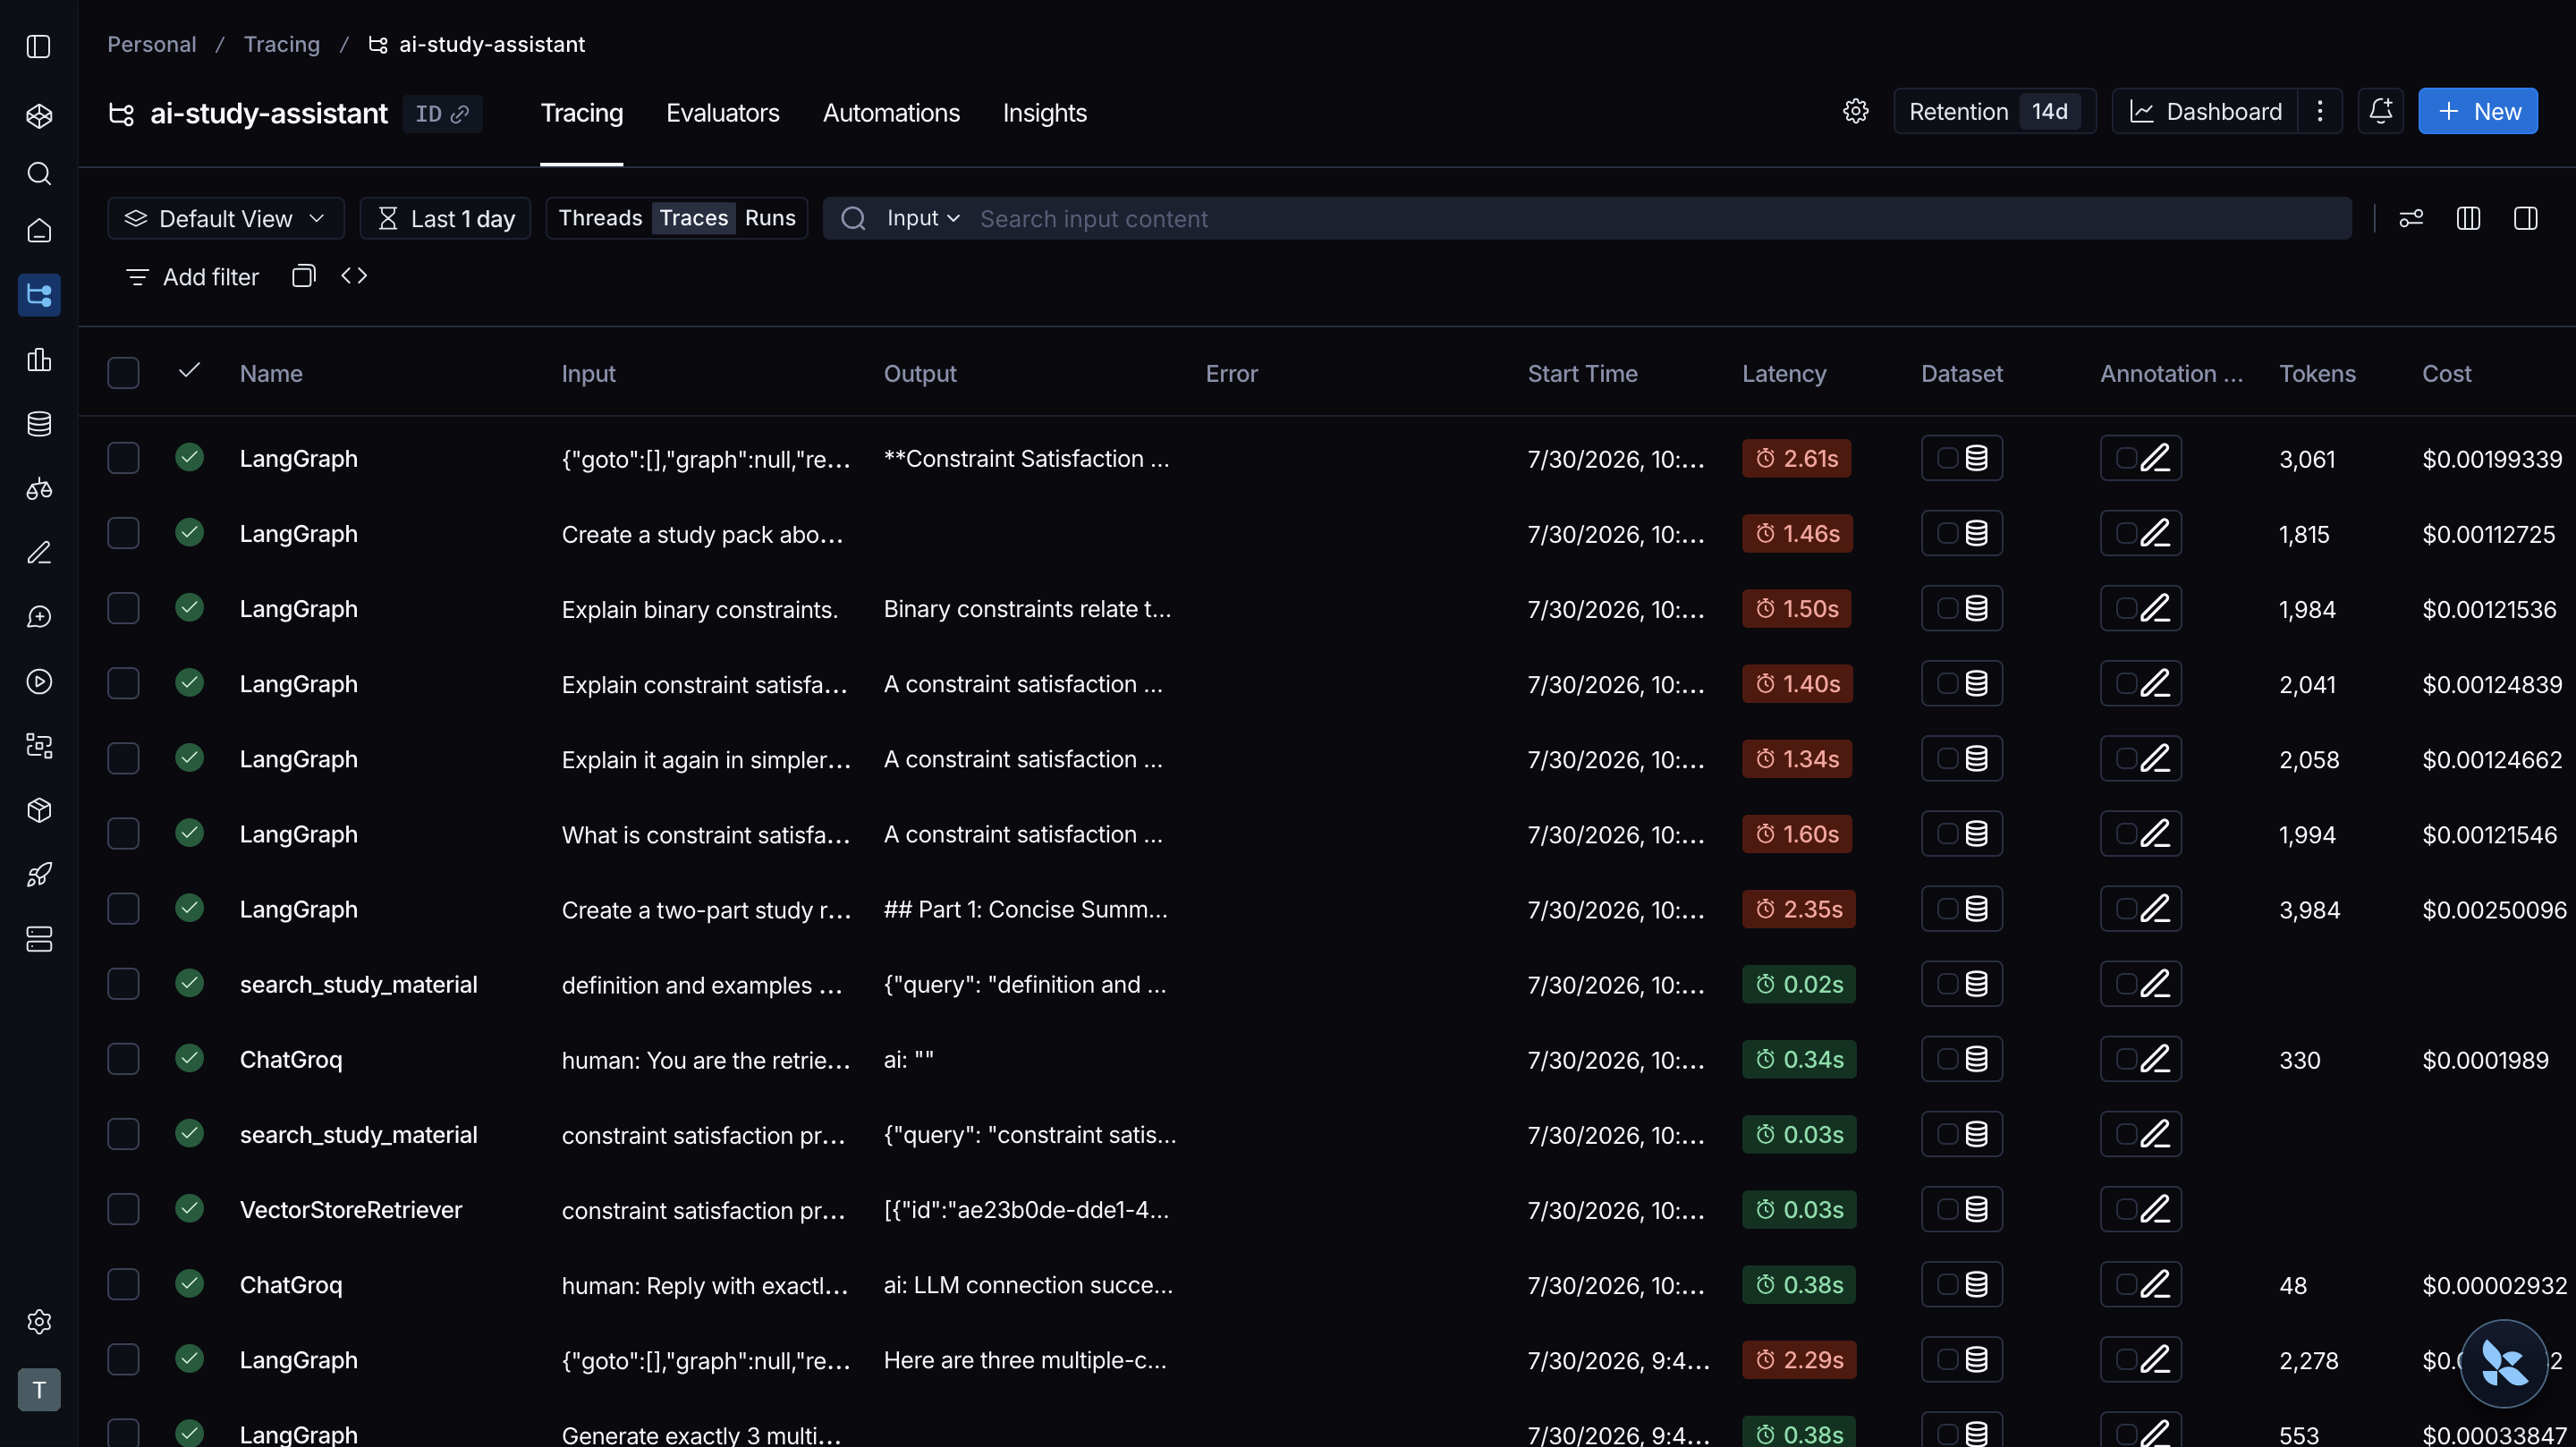

# Limitations and Future Improvements

- `InMemorySaver` and `InMemoryStore` are suitable for a capstone demonstration but should be replaced with durable database-backed implementations in production.
- Scanned or image-only PDFs require OCR.
- Tool selection uses Groq function calling for one simple retrieval decision; a direct grounded fallback is used if that decision call fails.
- Retrieval quality depends on PDF quality, chunking, and the embedding model.
- The notebook requires internet access for Groq and model downloads.
- Fresh LangSmith screenshots and measured latency findings must be captured after running the final code version.

# Conclusion

The final AI Study Assistant is an end-to-end multi-agent application built with the LangGraph Functional API. It uses a true Orchestrator–Worker pattern, model-selected retrieval tools, grounded 2-Step RAG, structured outputs, short-term and cross-thread long-term memory, Human-in-the-Loop approval, retry policies, safe fallbacks, and LangSmith observability.

The notebook contains executable demonstrations for multi-worker planning, cross-thread memory, interactive approval, and checkpoint resume safety. The remaining submission step is to run the final version and insert fresh LangSmith screenshots with a measured finding.